# HEART ATTACK RISK PREDICTION USING MACHINE LEARNING 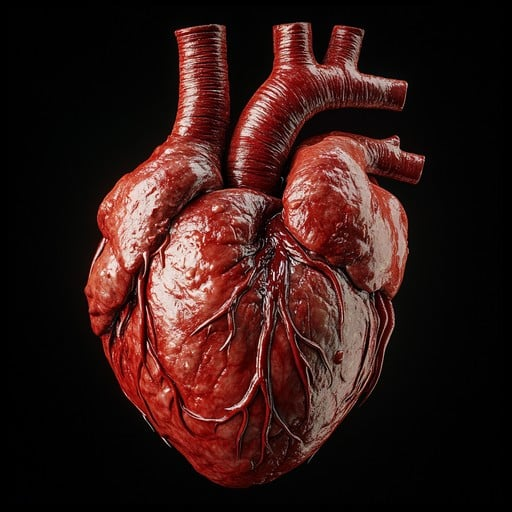

# ❤️ Phase 1: Introduction

## What is Heart Disease?

Heart disease refers to a group of conditions that affect the heart and blood vessels. It includes coronary artery disease, heart attack, heart failure, arrhythmias, and other cardiovascular disorders. These conditions can reduce the heart's ability to pump blood efficiently, leading to serious health complications. Heart disease is one of the leading causes of death worldwide, making early detection and prevention essential.

---

## Causes of Heart Disease

Heart disease develops due to a combination of lifestyle, genetic, and medical factors. Some common causes include:

- High blood pressure (Hypertension)
- High cholesterol levels
- Diabetes
- Smoking and tobacco use
- Obesity
- Physical inactivity
- Unhealthy diet
- Excessive alcohol consumption
- Stress and anxiety
- Family history of heart disease

---

## Symptoms of Heart Disease

The symptoms of heart disease may vary depending on the condition. Common symptoms include:

- Chest pain or discomfort (Angina)
- Shortness of breath
- Fatigue or weakness
- Rapid or irregular heartbeat
- Pain in the neck, jaw, shoulder, or arm
- Dizziness or fainting
- Swelling in the legs, ankles, or feet
- Nausea and cold sweats (especially during a heart attack)

---

## Risk Factors

Several factors increase the likelihood of developing heart disease:

- Older age
- Male gender (higher risk at younger ages)
- High blood pressure
- High cholesterol
- Diabetes
- Obesity
- Smoking
- Lack of physical activity
- Unhealthy eating habits
- Family history of cardiovascular disease
- Chronic stress

---

## Importance of Early Prediction

Early prediction of heart disease helps identify individuals at high risk before severe complications occur. Timely diagnosis enables healthcare professionals to recommend lifestyle changes, medications, and preventive treatments. Early intervention can significantly reduce the chances of heart attacks, improve patient outcomes, lower healthcare costs, and increase life expectancy.

---

## Machine Learning in Healthcare

Machine Learning (ML) is a branch of Artificial Intelligence (AI) that enables computers to learn patterns from historical data and make accurate predictions without being explicitly programmed. In healthcare, ML is widely used for disease diagnosis, medical image analysis, patient risk assessment, personalized treatment planning, and predicting health outcomes.

In this project, Machine Learning algorithms are trained on patient health records containing features such as age, blood pressure, cholesterol level, heart rate, BMI, diabetes status, smoking habits, and physical activity. The trained models analyze these factors to predict whether a person is at risk of developing heart disease, assisting doctors in making faster and more informed clinical decisions.

# PHASE 1 - Import Libraries and Load Dataset

In [1]:
# ============================================
# Heart Attack Risk Prediction Using Machine Learning
# Phase 1: Import Libraries and Load Dataset
# ============================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Plot Style
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving heart_attack_prediction_dataset.csv to heart_attack_prediction_dataset.csv


In [3]:
df = pd.read_csv("heart_attack_prediction_dataset.csv")
df

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,...,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,...,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,...,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,...,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0


In [4]:
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [5]:
df.shape

(8763, 26)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [7]:
df.isnull().sum()

,0
Patient ID,0
Age,0
Sex,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Diabetes,0
Family History,0
Smoking,0
Obesity,0


In [9]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
8758,False
8759,False
8760,False
8761,False


In [10]:
df.columns

Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk'],
      dtype='object')

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,8763.0,53.707977,21.249509,18.000000,35.000000,54.000000,72.000000,90.000000
Cholesterol,8763.0,259.877211,80.863276,120.000000,192.000000,259.000000,330.000000,400.000000
Heart Rate,8763.0,75.021682,20.550948,40.000000,57.000000,75.000000,93.000000,110.000000
Diabetes,8763.0,0.652288,0.476271,0.000000,0.000000,1.000000,1.000000,1.000000
Family History,8763.0,0.492982,0.499979,0.000000,0.000000,0.000000,1.000000,1.000000
Smoking,8763.0,0.896839,0.304186,0.000000,1.000000,1.000000,1.000000,1.000000
Obesity,8763.0,0.501426,0.500026,0.000000,0.000000,1.000000,1.000000,1.000000
Alcohol Consumption,8763.0,0.598083,0.490313,0.000000,0.000000,1.000000,1.000000,1.000000
Exercise Hours Per Week,8763.0,10.014284,5.783745,0.002442,4.981579,10.069559,15.050018,19.998709
Previous Heart Problems,8763.0,0.495835,0.500011,0.000000,0.000000,0.000000,1.000000,1.000000


In [12]:
df.tail()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,...,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,...,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,...,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,...,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0
8762,ZWN9666,25,Female,356,138/67,75,1,1,0,0,...,9.005234,247338,32.914151,180,7,4,United Kingdom,Europe,Northern Hemisphere,1


In [14]:
df.dtypes

,0
Patient ID,object
Age,int64
Sex,object
Cholesterol,int64
Blood Pressure,object
Heart Rate,int64
Diabetes,int64
Family History,int64
Smoking,int64
Obesity,int64


# PHASE 2 -  EXPLORATORY DATA ANALYSIS

# EDA 1: Target Variable Distribution

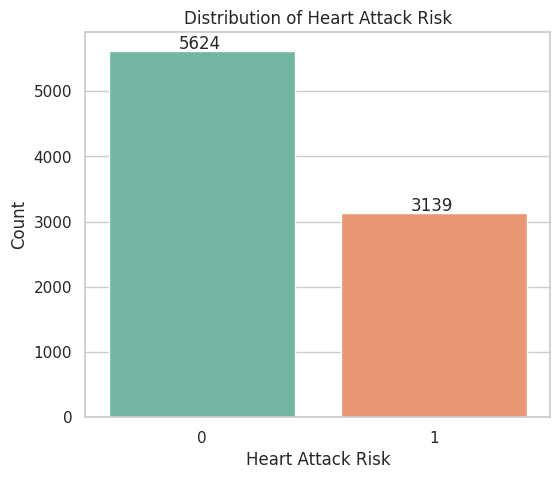

In [15]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Heart Attack Risk', palette='Set2')

plt.title('Distribution of Heart Attack Risk')
plt.xlabel('Heart Attack Risk')
plt.ylabel('Count')

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x()+0.3, p.get_height()+20))

plt.show()

### **Insights: Distribution of Heart Attack Risk**

* The target variable is **moderately imbalanced**, with **5,624 (64.2%)** individuals classified as **Low Risk (0)** and **3,139 (35.8%)** classified as **High Risk (1)**.

* Although the majority of records belong to the **Low Risk** class, the **High Risk** class still represents more than one-third of the dataset, making it sufficiently represented for machine learning model training.

* The class imbalance is **not severe**, but it should still be considered during model development to avoid bias toward the majority class.

* Performance metrics such as **Precision, Recall, F1-Score, ROC-AUC**, and the **Confusion Matrix** should be prioritized over accuracy alone to properly evaluate the model's ability to detect high-risk patients.

* If required, techniques such as **SMOTE (Synthetic Minority Oversampling Technique)**, **class weighting**, or **stratified train-test splitting** can be applied to improve prediction performance for the minority class.

* Overall, the dataset is **reasonably balanced** and is suitable for building reliable heart attack risk prediction models with appropriate evaluation strategies.


# EDA 2: Age Distribution

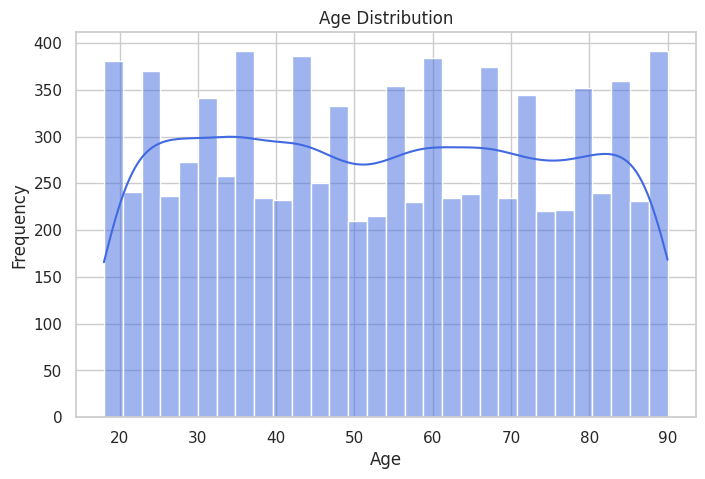

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True, color='royalblue')

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### **Insights: Age Distribution**

* The age of individuals ranges from **18 to 90 years**, indicating that the dataset includes a broad representation of the adult population.

* The histogram shows a **nearly uniform distribution** across different age groups, suggesting that no particular age category is overrepresented.

* The KDE (density) curve remains relatively flat, indicating that participants are distributed fairly evenly across the age range without significant peaks or skewness.

* There is **no evidence of extreme outliers or unusual age concentrations**, implying good data quality and balanced sampling.

* The balanced age distribution helps reduce age-related sampling bias and allows the machine learning model to learn patterns across both younger and older individuals.

* Since **age is a well-known clinical risk factor for heart disease**, further analysis should explore its relationship with the target variable (Heart Attack Risk) using box plots, violin plots, or grouped bar charts.


# EDA 3: Cholesterol Distribution

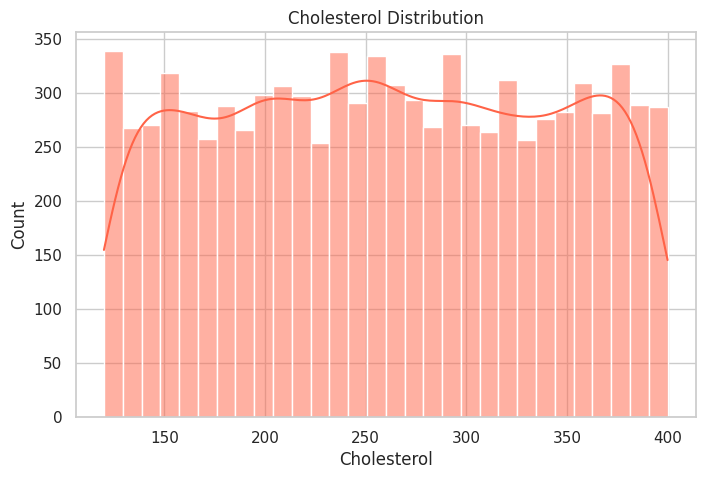

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Cholesterol'], bins=30, kde=True, color='tomato')

plt.title('Cholesterol Distribution')
plt.xlabel('Cholesterol')
plt.show()

### **Insights: Cholesterol Distribution**

* The cholesterol values range from approximately **120 mg/dL to 400 mg/dL**, covering normal, borderline, and high cholesterol levels.

* The histogram indicates a **fairly uniform distribution** of cholesterol values across the dataset, with no single range dominating the observations.

* The KDE (density) curve remains relatively flat with only minor fluctuations, suggesting that cholesterol levels are evenly represented rather than concentrated around a specific value.

* There is **no significant skewness or extreme outliers**, indicating good data quality and a well-distributed numerical feature.

* The wide range of cholesterol values enables the machine learning model to learn patterns across individuals with both healthy and elevated cholesterol levels.

* Since **high cholesterol is a major risk factor for cardiovascular disease**, further analysis should examine its relationship with **Heart Attack Risk** using box plots, violin plots, or correlation analysis to determine its predictive importance.


# EDA 4: BMI Distribution

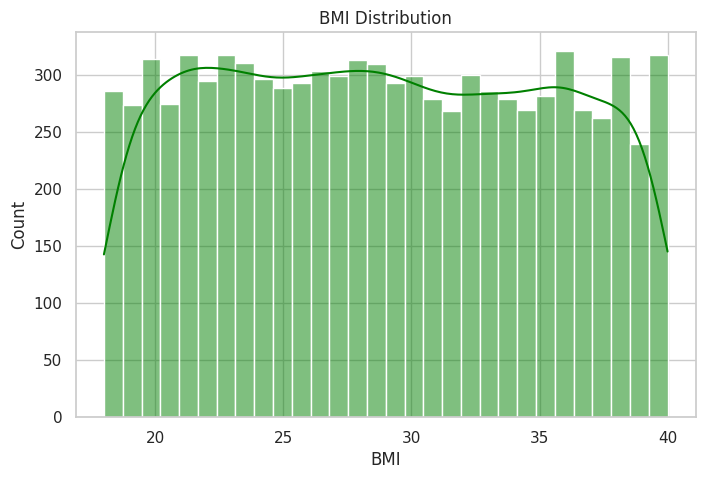

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['BMI'], bins=30, kde=True, color='green')

plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.show()

### **Insights: BMI Distribution**

* The BMI values range from approximately **18 to 40 kg/m²**, covering individuals from the **normal weight** category to **obesity**.

* The histogram shows a **fairly uniform distribution** of BMI values across the entire range, indicating that the dataset contains a balanced representation of different body weight categories.

* The KDE (density) curve is relatively flat with only minor fluctuations, suggesting that no single BMI range is overly dominant in the dataset.

* There is **no noticeable skewness or presence of extreme outliers**, indicating good data quality and a well-distributed numerical feature.

* The inclusion of participants with both healthy and elevated BMI levels enables the machine learning model to effectively learn the relationship between body weight and heart attack risk.

* Since **high BMI is a significant risk factor for cardiovascular diseases**, further analysis should compare BMI across **Heart Attack Risk** groups using box plots, violin plots, or statistical tests to assess its impact on the target variable.


# EDA 5: Heart Rate Distribution

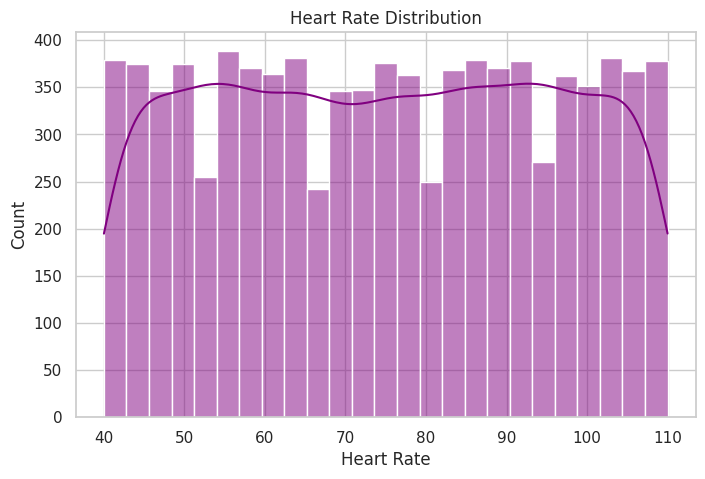

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Heart Rate'], bins=25, kde=True, color='purple')

plt.title('Heart Rate Distribution')
plt.xlabel('Heart Rate')
plt.show()

### **Insights: Heart Rate Distribution**

* The heart rate values range from approximately **40 to 110 beats per minute (bpm)**, representing a wide spectrum of resting heart rates among individuals.

* The histogram shows a **fairly uniform distribution** across the entire range, indicating that participants with low, normal, and relatively high heart rates are well represented in the dataset.

* The KDE (density) curve remains relatively stable with only minor fluctuations, suggesting there is **no strong concentration around a specific heart rate value**.

* There is **no significant skewness or presence of extreme outliers**, indicating that the heart rate feature is well distributed and suitable for machine learning analysis.

* The balanced distribution allows the model to learn patterns across different heart rate levels without bias toward a particular range.

* Since **abnormal heart rate can be associated with cardiovascular conditions**, further analysis should investigate its relationship with **Heart Attack Risk** using box plots, violin plots, or feature importance analysis to determine its predictive value.


# EDA 6: Age vs Heart Attack Risk

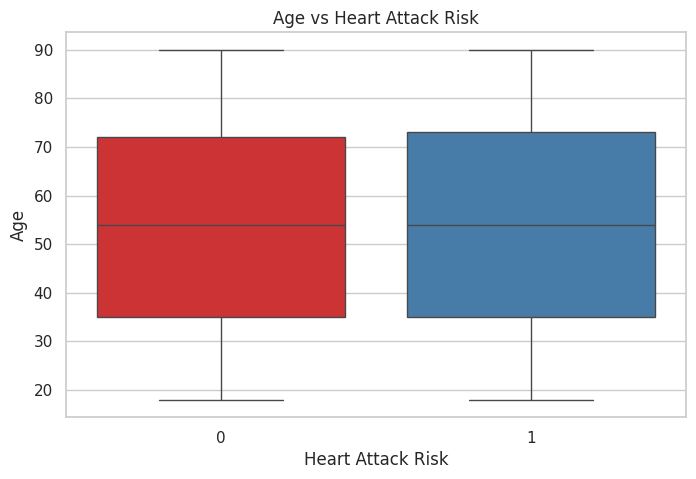

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='Heart Attack Risk',
            y='Age',
            palette='Set1')

plt.title('Age vs Heart Attack Risk')
plt.show()

### **Insights: Age vs Heart Attack Risk**

* The box plots show that the **age distributions for both Low Risk (0) and High Risk (1) groups are very similar**, with nearly identical median ages of approximately **54 years**.

* Both groups exhibit a **wide age range (18 to 90 years)**, indicating that individuals of all adult age categories are represented in both classes.

* The **interquartile range (IQR)** is almost the same for both groups, suggesting that the middle 50% of observations have a similar spread of ages regardless of heart attack risk.

* There is a **substantial overlap between the two distributions**, implying that **age alone does not clearly distinguish** between individuals with low and high heart attack risk in this dataset.

* No significant outliers are observed, indicating consistent age data with no unusually extreme values affecting the analysis.

* These findings suggest that while **age is an important cardiovascular risk factor**, it is likely to be **more predictive when combined with other clinical variables** such as cholesterol, blood pressure, BMI, diabetes, smoking status, and physical activity, rather than being used as a standalone predictor.


# EDA 7: Cholesterol vs Heart Attack Risk

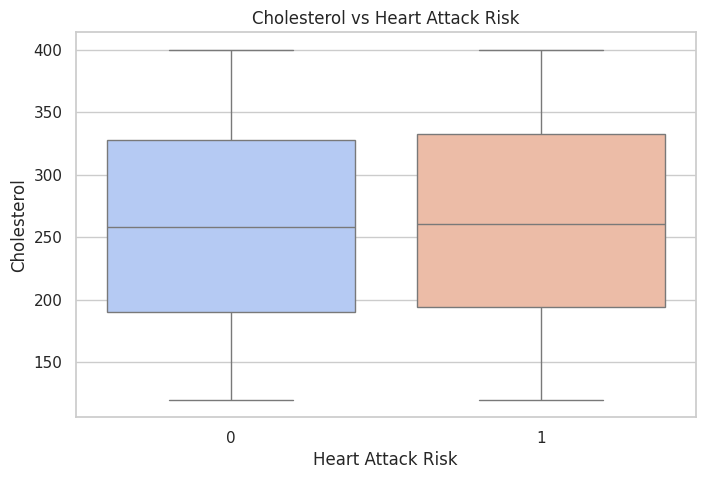

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='Heart Attack Risk',
            y='Cholesterol',
            palette='coolwarm')

plt.title('Cholesterol vs Heart Attack Risk')
plt.show()

### **Insights: Cholesterol vs Heart Attack Risk**

* The box plots indicate that the **cholesterol distributions for both Low Risk (0) and High Risk (1) groups are highly similar**, with median cholesterol levels around **260 mg/dL**.

* Both groups exhibit a **wide cholesterol range (120 to 400 mg/dL)**, showing that individuals with low and high cholesterol levels are present in each risk category.

* The **interquartile range (IQR)** is nearly identical for both groups, indicating similar variability in cholesterol levels across the two classes.

* There is a **considerable overlap between the two box plots**, suggesting that **cholesterol alone does not clearly separate individuals with low and high heart attack risk** in this dataset.

* No significant outliers are observed, indicating that cholesterol values are consistently distributed and free from extreme abnormalities.

* Although **high cholesterol is a well-established cardiovascular risk factor**, this analysis suggests that its predictive ability improves when combined with other variables such as **age, blood pressure, BMI, diabetes, smoking status, and physical activity** rather than being used as an isolated predictor.


# EDA 8: BMI vs Heart Attack Risk

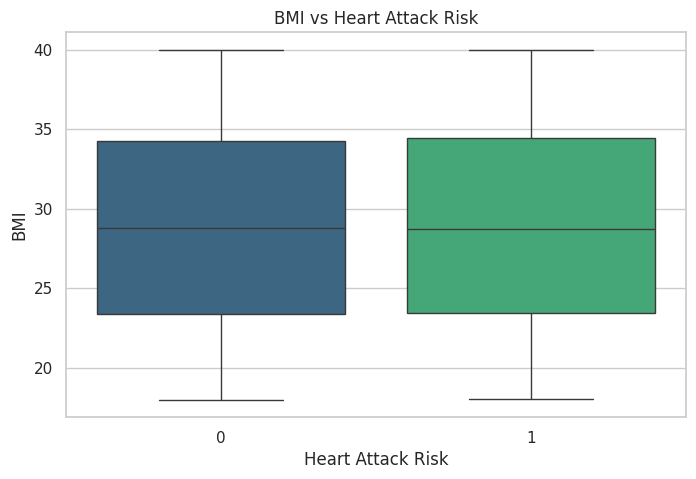

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='Heart Attack Risk',
            y='BMI',
            palette='viridis')

plt.title('BMI vs Heart Attack Risk')
plt.show()

### **Insights: BMI vs Heart Attack Risk**

* The box plots show that the **BMI distributions for both Low Risk (0) and High Risk (1) groups are almost identical**, with median BMI values around **29 kg/m²**.

* Both groups have a **BMI range of approximately 18 to 40 kg/m²**, indicating that individuals across normal, overweight, and obese categories are represented in both risk groups.

* The **interquartile range (IQR)** is nearly the same for both classes, suggesting similar variability in BMI among low-risk and high-risk individuals.

* There is a **high degree of overlap** between the two box plots, indicating that **BMI alone does not effectively distinguish between individuals with low and high heart attack risk** in this dataset.

* No significant outliers are observed, suggesting that the BMI values are consistent and free from extreme observations.

* Although **higher BMI is a recognized risk factor for cardiovascular disease**, this visualization indicates that **BMI should be evaluated alongside other clinical and lifestyle factors** such as age, cholesterol, blood pressure, diabetes, smoking status, and physical activity to improve heart attack risk prediction.


# EDA 9: Smoking vs Heart Attack Risk

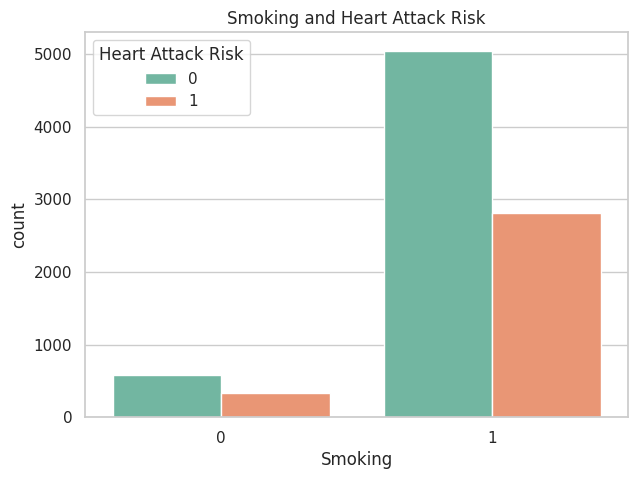

In [23]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,
              x='Smoking',
              hue='Heart Attack Risk',
              palette='Set2')

plt.title('Smoking and Heart Attack Risk')
plt.show()

### **Insights: Smoking vs Heart Attack Risk**

* The majority of individuals in the dataset are **smokers (Smoking = 1)**, while only a small proportion are **non-smokers (Smoking = 0)**.

* Among both **smokers** and **non-smokers**, the number of **Low Risk (0)** individuals is higher than the number of **High Risk (1)** individuals.

* A significantly larger number of **heart attack risk cases** are observed among smokers. However, this is largely because **smokers constitute the majority of the dataset**, not necessarily because smoking alone increases the observed risk in this chart.

* The count plot displays **absolute frequencies rather than proportions**, so it should not be used alone to conclude that smoking directly causes a higher heart attack risk.

* To better understand the relationship, a **normalized percentage plot (100% stacked bar chart)** or **Heart Attack Risk rate by Smoking status** would provide a more accurate comparison.

* Since **smoking is a well-established cardiovascular risk factor**, it is expected to contribute to heart attack risk when analyzed together with other variables such as **age, cholesterol, blood pressure, BMI, diabetes, and physical activity** in the machine learning model.


# EDA 10: Diabetes vs Heart Attack Risk

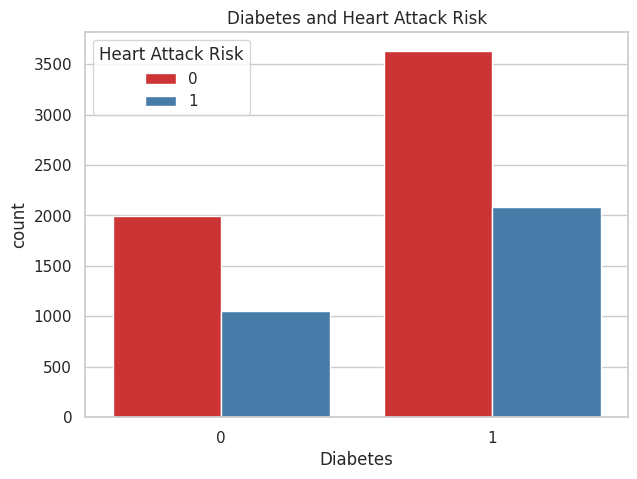

In [24]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,
              x='Diabetes',
              hue='Heart Attack Risk',
              palette='Set1')

plt.title('Diabetes and Heart Attack Risk')
plt.show()

### **Insights: Diabetes vs Heart Attack Risk**

* The dataset contains **more individuals with diabetes (Diabetes = 1)** than without diabetes (Diabetes = 0).

* In both diabetic and non-diabetic groups, the number of **Low Risk (0)** individuals is higher than the number of **High Risk (1)** individuals.

* A greater number of **heart attack risk cases** is observed among individuals with diabetes. However, this is influenced by the fact that **the diabetic group contains more observations** than the non-diabetic group.

* The count plot presents **absolute frequencies**, so it does not directly indicate that diabetes leads to a higher heart attack risk. A comparison of **risk percentages within each diabetes group** would provide a more meaningful interpretation.

* The overlap between the two heart attack risk classes suggests that **diabetes alone is not sufficient to distinguish high-risk individuals** and should be evaluated together with other clinical variables.

* Since **diabetes is a well-established cardiovascular risk factor**, it is expected to play an important role in heart attack prediction when combined with features such as **age, cholesterol, blood pressure, BMI, smoking status, and physical activity** in the machine learning model.


# EDA 11: Correlation Heatmap

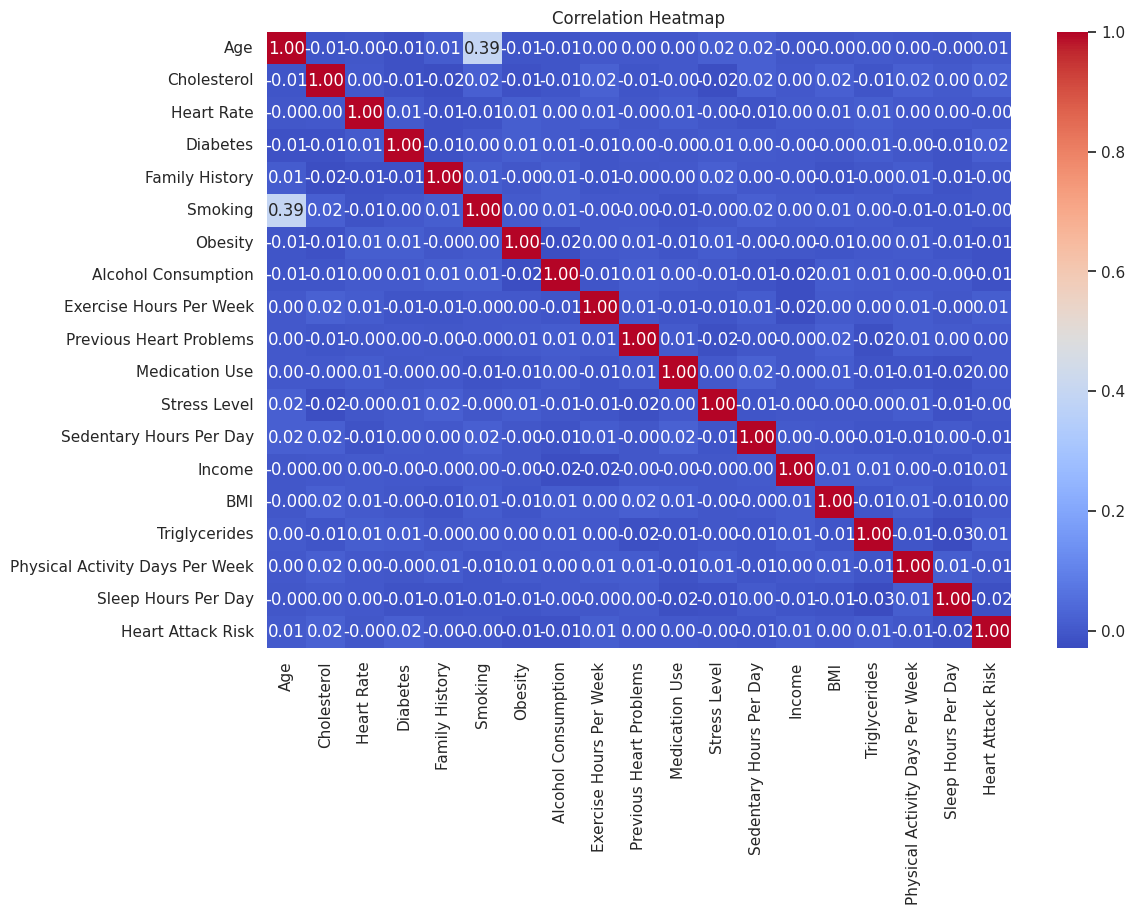

In [25]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

### **Insights: Correlation Heatmap**

* The correlation heatmap indicates that **most numerical features have very weak linear correlations** with one another, with correlation coefficients generally close to **0**, suggesting minimal multicollinearity in the dataset.

* The strongest positive correlation is observed between **Age** and **Smoking** (**r ≈ 0.39**), indicating a moderate positive relationship where smoking prevalence tends to increase with age in this dataset.

* The target variable, **Heart Attack Risk**, shows **very weak individual correlations** with all numerical features (correlation coefficients close to **0**), suggesting that no single feature alone is a strong linear predictor of heart attack risk.

* Features such as **Cholesterol, BMI, Heart Rate, Diabetes, Triglycerides, Stress Level, Exercise Hours, and Sleep Hours** exhibit negligible pairwise correlations, indicating that they contribute largely independent information.

* The absence of strong correlations (typically **|r| > 0.7**) suggests that **multicollinearity is not a significant concern**, making the dataset suitable for machine learning algorithms without requiring extensive feature removal.

* Since heart attack risk is influenced by the **combined effect of multiple clinical and lifestyle factors**, advanced machine learning models such as **Random Forest, XGBoost, Gradient Boosting, or CatBoost** are likely to capture these complex, non-linear relationships more effectively than relying on simple correlation analysis alone.


# EDA 12: Pairplot

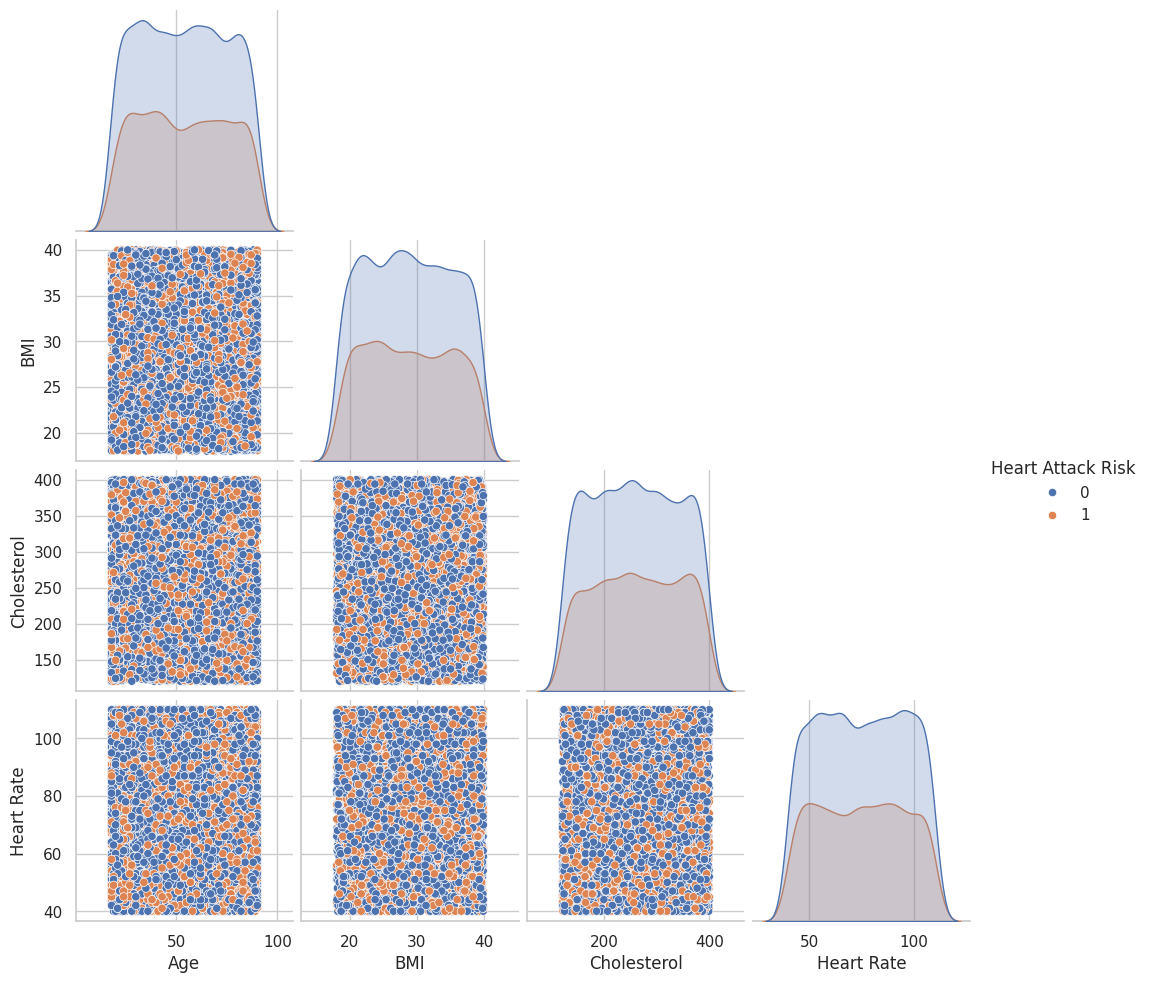

In [26]:
selected_features = [
    'Age',
    'BMI',
    'Cholesterol',
    'Heart Rate',
    'Heart Attack Risk'
]

sns.pairplot(df[selected_features],
             hue='Heart Attack Risk',
             corner=True)

plt.show()

### **Insights: Pair Plot of Age, BMI, Cholesterol, and Heart Rate**

* The pair plot illustrates the relationships between **Age, BMI, Cholesterol, and Heart Rate**, with observations colored according to **Heart Attack Risk (0 = Low Risk, 1 = High Risk)**.

* The **diagonal density plots** show that all four numerical features are **fairly evenly distributed**, with similar distributions for both low-risk and high-risk individuals.

* The **scatter plots** reveal **no strong linear relationship** between any pair of variables. Data points are widely dispersed, indicating weak correlations among these features.

* The **Low Risk (0)** and **High Risk (1)** classes are **highly overlapping** across all feature combinations, suggesting that these variables alone do not clearly separate the two heart attack risk groups.

* No distinct clusters or decision boundaries are visible, indicating that **heart attack risk cannot be accurately predicted using a single feature or a simple linear relationship**.

* The absence of noticeable outliers or abnormal patterns suggests that the dataset is **clean and well-distributed**, making it suitable for machine learning analysis.

* The strong overlap between classes indicates that **Heart Attack Risk is likely influenced by the combined effect of multiple clinical and lifestyle factors**, rather than any single variable.

* These findings support the use of **advanced machine learning algorithms** such as **Random Forest, XGBoost, Gradient Boosting, AdaBoost, or CatBoost**, which can capture complex, non-linear interactions among multiple features and provide more accurate predictions than simple statistical methods.


# EDA 13  Feature-wise Outlier Detection

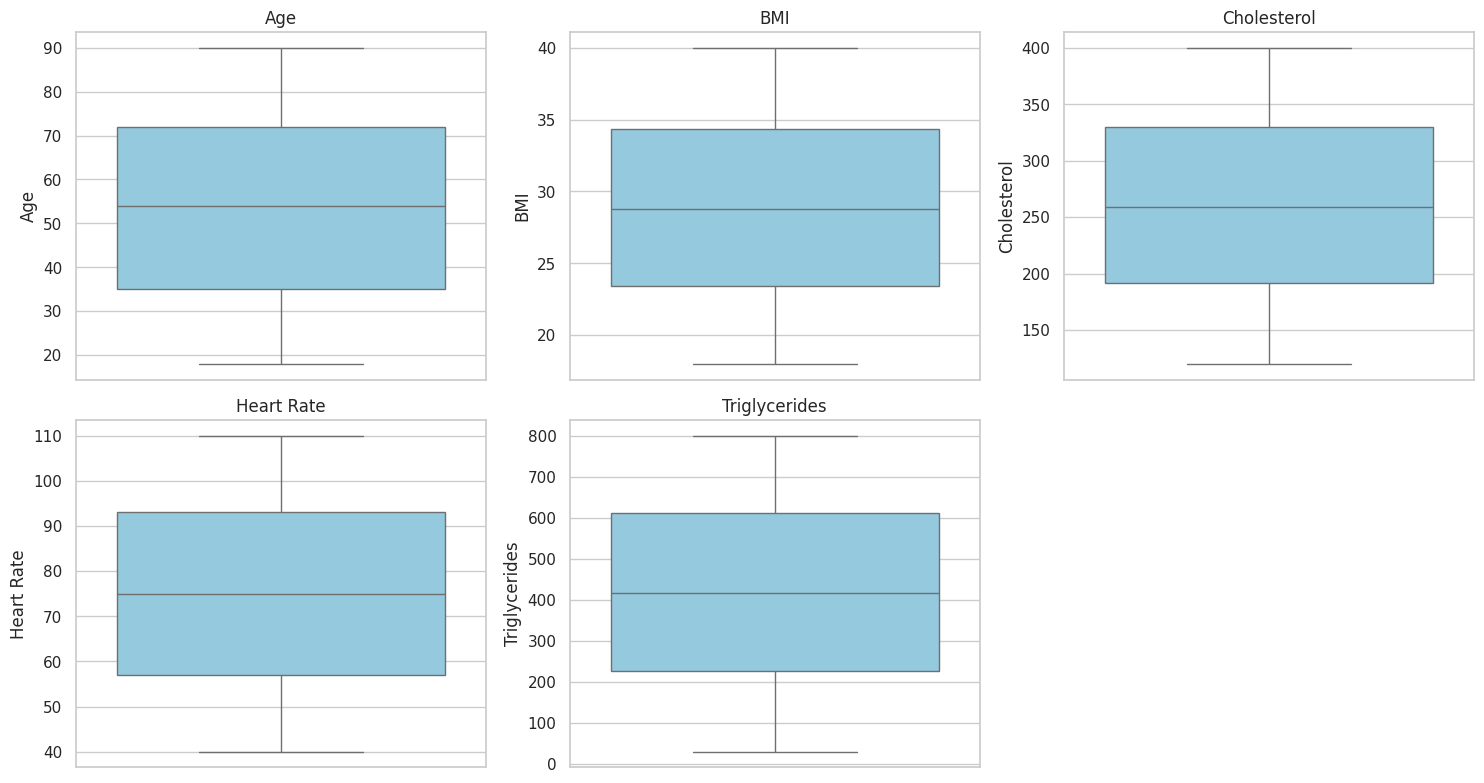

In [27]:
num_cols = ['Age','BMI','Cholesterol','Heart Rate','Triglycerides']

plt.figure(figsize=(15,8))

for i,col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

### **Insights: Box Plots of Numerical Features**

* The box plots summarize the distribution of **Age, BMI, Cholesterol, Heart Rate, and Triglycerides**, providing insights into their central tendency, spread, and potential outliers.

* **Age** ranges from approximately **18 to 90 years**, with a median around **54 years**. The distribution is balanced, and no significant outliers are observed.

* **BMI** values range from **18 to 40 kg/m²**, with a median close to **29 kg/m²**. The spread is fairly uniform, indicating representation of individuals from normal weight to obese categories.

* **Cholesterol** ranges from approximately **120 to 400 mg/dL**, with a median around **260 mg/dL**. The wide interquartile range suggests considerable variability in cholesterol levels across the dataset.

* **Heart Rate** varies between **40 and 110 bpm**, with a median of approximately **75 bpm**. The distribution is symmetric with no noticeable extreme values.

* **Triglyceride** levels show the **widest range** among all features, spanning from approximately **30 to 800 mg/dL**, with a median around **420 mg/dL**, indicating substantial variability across individuals.

* None of the numerical features display **significant outliers**, suggesting that the dataset is clean and does not require extensive outlier treatment before model development.

* The moderate spread across all variables indicates that the dataset captures a diverse population, which is beneficial for training robust and generalizable machine learning models.

* Since no single feature exhibits an unusual distribution or extreme observations, these variables can be retained for feature engineering and model training without major preprocessing related to outlier removal.


#  EDA 14 Lifestyle Factors vs Heart Attack Risk

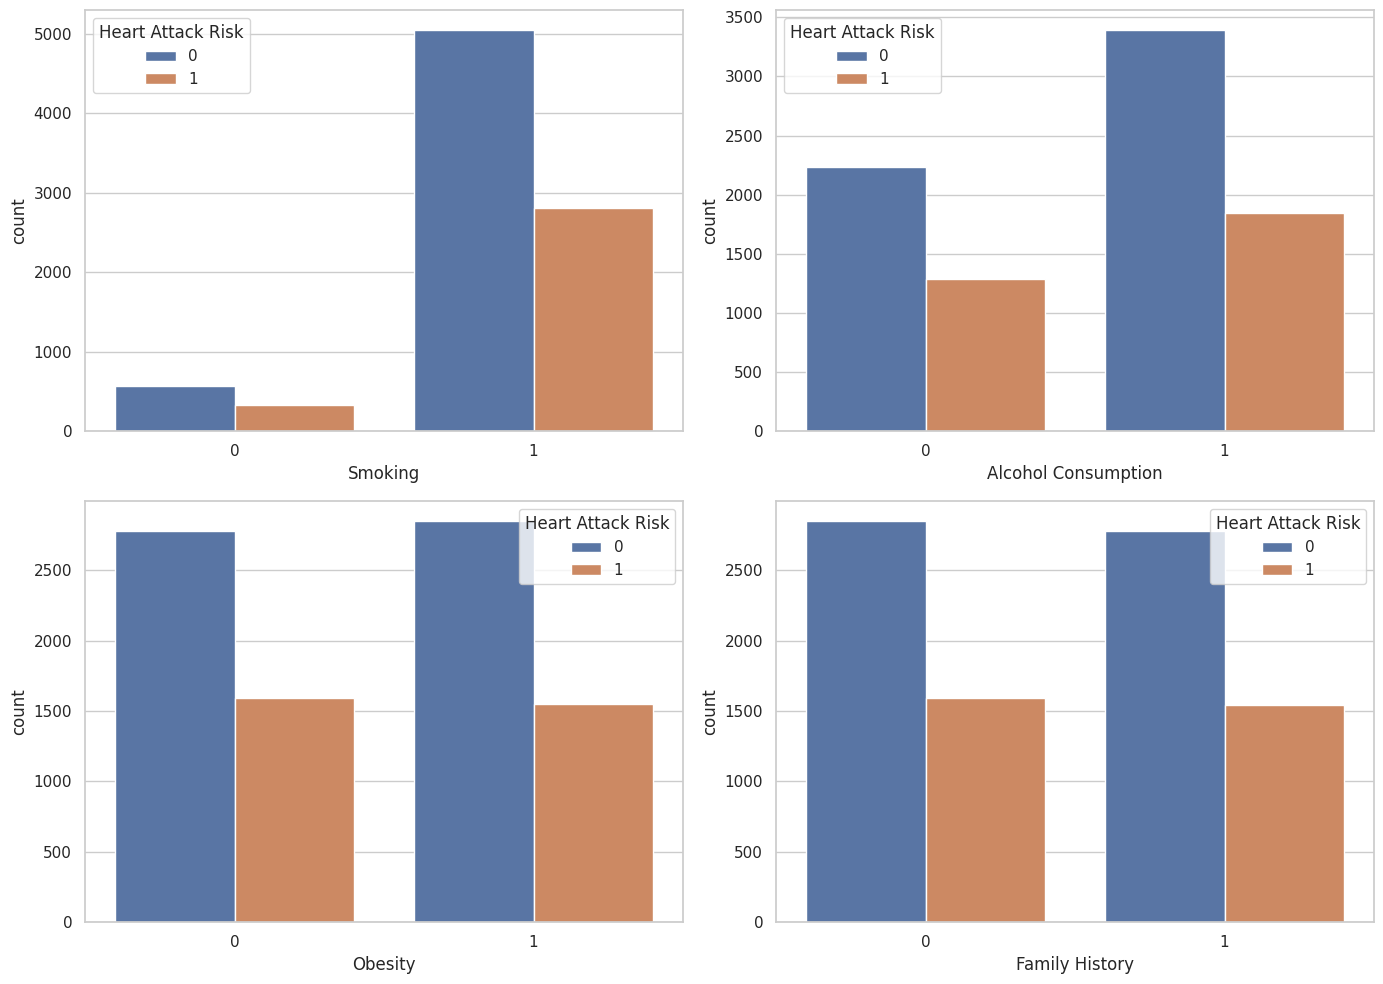

In [28]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.countplot(data=df, x='Smoking', hue='Heart Attack Risk', ax=axes[0,0])

sns.countplot(data=df, x='Alcohol Consumption', hue='Heart Attack Risk', ax=axes[0,1])

sns.countplot(data=df, x='Obesity', hue='Heart Attack Risk', ax=axes[1,0])

sns.countplot(data=df, x='Family History', hue='Heart Attack Risk', ax=axes[1,1])

plt.tight_layout()
plt.show()

### **Insights: Categorical Features vs Heart Attack Risk**

#### **1. Smoking vs Heart Attack Risk**

* The majority of individuals in the dataset are **smokers (Smoking = 1)**, while relatively few are non-smokers.
* In both smoking categories, **Low Risk (0)** cases outnumber **High Risk (1)** cases.
* More high-risk cases are observed among smokers, but this is influenced by the larger number of smokers in the dataset.
* A percentage-based comparison would provide a clearer understanding of smoking's impact on heart attack risk.

#### **2. Alcohol Consumption vs Heart Attack Risk**

* Individuals with **Alcohol Consumption = 1** are more prevalent than those with **Alcohol Consumption = 0**.
* Both alcohol consumption groups contain more low-risk than high-risk individuals.
* The distributions are fairly similar, indicating that **alcohol consumption alone does not clearly distinguish heart attack risk**.
* Its predictive value is likely enhanced when analyzed with other health and lifestyle factors.

#### **3. Obesity vs Heart Attack Risk**

* The numbers of obese and non-obese individuals are relatively balanced in the dataset.
* Both groups show a similar pattern where **Low Risk (0)** cases exceed **High Risk (1)** cases.
* The difference in heart attack risk between obese and non-obese individuals is not substantial based on this count plot alone.
* This suggests that **obesity should be evaluated alongside other clinical variables** rather than as an independent predictor.

#### **4. Family History vs Heart Attack Risk**

* Individuals with and without a **family history of heart disease** are almost equally represented.
* Both categories contain more low-risk than high-risk individuals.
* The similarity in the distributions indicates that **family history alone does not clearly separate high-risk and low-risk individuals** in this dataset.
* However, family history remains an important clinical factor and may contribute more effectively when combined with other predictors in the machine learning model.

### **Overall Observation**

* Across all four categorical variables, the **Low Risk (0)** class consistently has more observations than the **High Risk (1)** class.
* None of these features individually show a strong separation between heart attack risk groups based on count plots.
* Since these plots display **absolute counts rather than proportions**, they should not be used alone to infer the strength of association.
* These findings suggest that **heart attack risk is influenced by the combined effect of multiple clinical and lifestyle factors**, reinforcing the need for machine learning models capable of capturing complex interactions among features.


# EDA 15 Average Heart Attack Risk by Lifestyle Factors ⭐⭐⭐⭐⭐

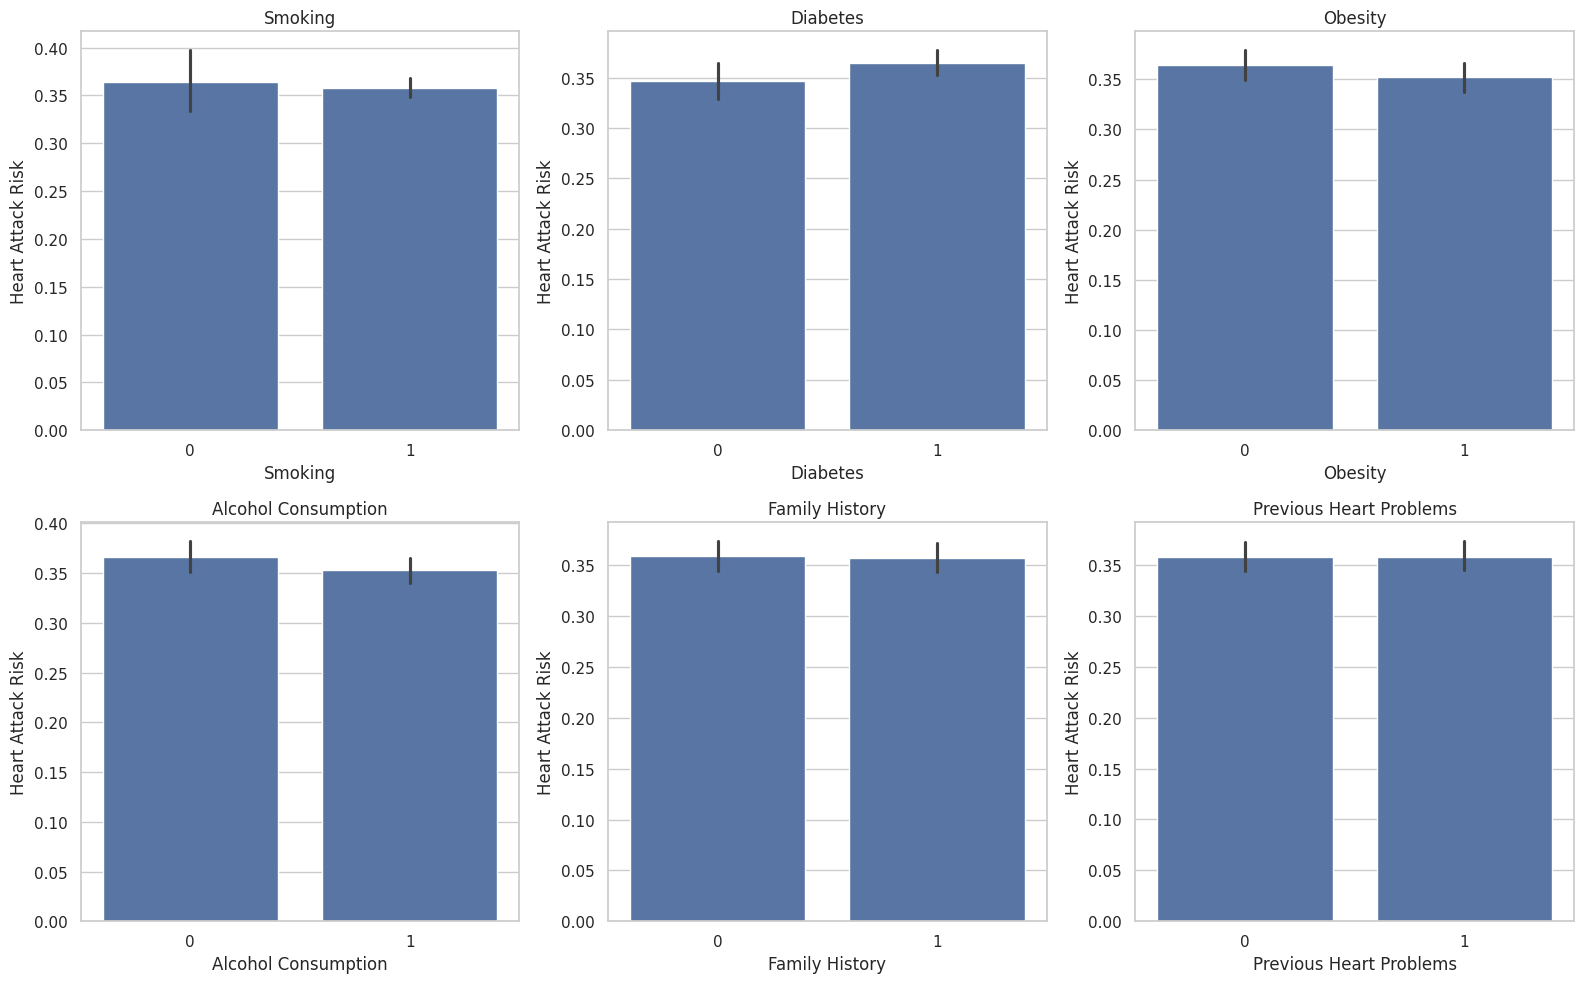

In [29]:
risk_cols = ['Smoking','Diabetes','Obesity',
             'Alcohol Consumption',
             'Family History',
             'Previous Heart Problems']

fig, axes = plt.subplots(2,3, figsize=(16,10))

for ax,col in zip(axes.flatten(), risk_cols):
    sns.barplot(data=df,
                x=col,
                y='Heart Attack Risk',
                estimator=np.mean,
                ax=ax)

    ax.set_title(col)

plt.tight_layout()
plt.show()

### **Insights: Mean Heart Attack Risk Across Categorical Features**

#### **1. Smoking**

* The average heart attack risk is **very similar** for both smokers and non-smokers.
* Non-smokers show a **slightly higher mean risk** than smokers, but the difference is minimal.
* This suggests that **smoking alone is not a strong independent predictor** of heart attack risk in this dataset.

#### **2. Diabetes**

* Individuals with **diabetes (1)** exhibit a **slightly higher average heart attack risk** compared to those without diabetes.
* Although the difference is modest, diabetes appears to have a **positive association** with heart attack risk.
* This finding is consistent with diabetes being an important cardiovascular risk factor.

#### **3. Obesity**

* Non-obese and obese individuals have **very similar mean heart attack risk values**.
* The slight difference between the two groups indicates that **obesity alone does not substantially influence heart attack risk** in this dataset.
* Its predictive contribution is likely stronger when combined with other clinical variables.

#### **4. Alcohol Consumption**

* Individuals without alcohol consumption show a **slightly higher average heart attack risk** than those who consume alcohol.
* The difference is relatively small, suggesting that **alcohol consumption alone has limited predictive power** for heart attack risk in this dataset.

#### **5. Family History**

* The average heart attack risk is **nearly identical** for individuals with and without a family history of heart disease.
* This indicates that **family history alone does not clearly differentiate** between low-risk and high-risk individuals.

#### **6. Previous Heart Problems**

* Individuals with and without previous heart problems exhibit **almost the same mean heart attack risk**.
* The minimal difference suggests that this feature alone is **not sufficient to explain variations in heart attack risk**.

### **Overall Observation**

* Across all six categorical variables, the **mean heart attack risk remains within a narrow range (approximately 0.35–0.37)**.
* **Diabetes** shows the **highest average heart attack risk**, while the remaining variables exhibit only minor differences between categories.
* The overlapping confidence intervals indicate that many of these differences may not be statistically significant.
* These results suggest that **no single categorical feature strongly determines heart attack risk**. Instead, heart attack risk is likely influenced by the **combined interaction of multiple demographic, clinical, and lifestyle factors**, highlighting the importance of machine learning models that can capture complex, non-linear relationships among features.


# Phase 3 : Data Preprocessing & Feature Engineering

# 1 Drop Unnecessary Columns

In [30]:
# Drop ID column
df.drop('Patient ID', axis=1, inplace=True)

print("Patient ID column removed.")

Patient ID column removed.


# 2. Split Blood Pressure into Two Features

In [31]:
# Split Blood Pressure
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)

# Convert to integer
df['Systolic_BP'] = df['Systolic_BP'].astype(int)
df['Diastolic_BP'] = df['Diastolic_BP'].astype(int)

# Remove original column
df.drop('Blood Pressure', axis=1, inplace=True)

df.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,Systolic_BP,Diastolic_BP
0,67,Male,208,72,0,0,1,0,0,4.168189,...,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0,158,88
1,21,Male,389,98,1,1,1,1,1,1.813242,...,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0,165,93
2,21,Female,324,72,1,0,0,0,0,2.078353,...,28.176571,587,4,4,France,Europe,Northern Hemisphere,0,174,99
3,84,Male,383,73,1,1,1,0,1,9.828130,...,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0,163,100
4,66,Male,318,93,1,1,1,1,0,5.804299,...,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0,91,88


# 3. Encode Categorical Variables

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


# 4. Verify Data Types

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8763 non-null   int64  
 1   Sex                              8763 non-null   int64  
 2   Cholesterol                      8763 non-null   int64  
 3   Heart Rate                       8763 non-null   int64  
 4   Diabetes                         8763 non-null   int64  
 5   Family History                   8763 non-null   int64  
 6   Smoking                          8763 non-null   int64  
 7   Obesity                          8763 non-null   int64  
 8   Alcohol Consumption              8763 non-null   int64  
 9   Exercise Hours Per Week          8763 non-null   float64
 10  Diet                             8763 non-null   int64  
 11  Previous Heart Problems          8763 non-null   int64  
 12  Medication Use      

# 5. Define Features and Target

In [34]:
X = df.drop('Heart Attack Risk', axis=1)
y = df['Heart Attack Risk']

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (8763, 25)
Target Shape : (8763,)


# 6. Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 7. SMOTE

In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE")
print(X_train.shape)
print(y_train.value_counts())

After SMOTE
(8998, 25)
Heart Attack Risk
0    4499
1    4499
Name: count, dtype: int64


# 8. Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9. Check Class Distribution

In [39]:
print("Class Distribution After SMOTE\n")
print(y_train.value_counts())

print("\nPercentage Distribution After SMOTE\n")
print((y_train.value_counts(normalize=True) * 100).round(2))

Class Distribution After SMOTE

Heart Attack Risk
0    4499
1    4499
Name: count, dtype: int64

Percentage Distribution After SMOTE

Heart Attack Risk
0    50.0
1    50.0
Name: proportion, dtype: float64


# 10. Visualize Class Balance

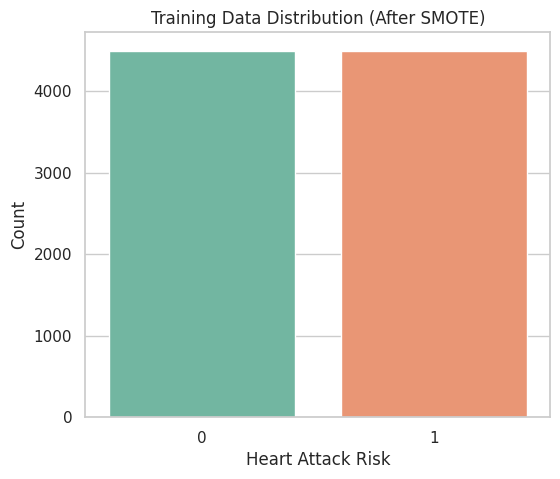

In [40]:
plt.figure(figsize=(6,5))

sns.countplot(x=y_train, palette='Set2')

plt.title("Training Data Distribution (After SMOTE)")
plt.xlabel("Heart Attack Risk")
plt.ylabel("Count")

plt.show()

# 11 FINAL PREPROCESSING SUMMARY

In [41]:
print("=" * 50)
print("PREPROCESSING SUMMARY")
print("=" * 50)

print(f"Final Dataset Shape            : {df.shape}")
print(f"Total Features                : {X.shape[1]}")
print(f"Target Variable               : Heart Attack Risk")
print(f"Original Training Samples     : {X_test.shape[0] + (len(y) - len(y_test)) if False else 'See below'}")
print(f"Training Samples After SMOTE  : {X_train.shape[0]}")
print(f"Testing Samples               : {X_test.shape[0]}")
print("Categorical Encoding          : Completed")
print("SMOTE Balancing               : Applied")
print("Feature Scaling              : Completed")
print("Dataset Status               : Ready for Model Training")

PREPROCESSING SUMMARY
Final Dataset Shape            : (8763, 26)
Total Features                : 25
Target Variable               : Heart Attack Risk
Original Training Samples     : See below
Training Samples After SMOTE  : 8998
Testing Samples               : 1753
Categorical Encoding          : Completed
SMOTE Balancing               : Applied
Feature Scaling              : Completed
Dataset Status               : Ready for Model Training


# Phase 4 : Model Building and Evaluation

# Step 1: Import Machine Learning Models

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Step 2: Create Model Dictionary

In [43]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

# Step 3: Import Evaluation Metrics

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

# Step 4: Train and Evaluate All Models

In [45]:
results = []

for name, model in models.items():

    # Models requiring scaled data
    if name in ["Logistic Regression", "KNN", "SVM", "Naive Bayes"]:

        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        prob = model.predict_proba(X_test_scaled)[:,1]

    # Tree-based models
    else:

        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, prob)
    })

print("All models trained successfully.")

All models trained successfully.


# Step 5: Create Comparison Table

In [46]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.579578,0.353100,0.208599,0.262262,0.496573
4,SVM,0.571021,0.340206,0.210191,0.259843,0.485301
6,Gradient Boosting,0.559042,0.365989,0.315287,0.338751,0.503094
8,XGBoost,0.556189,0.361624,0.312102,0.335043,0.515139
5,Naive Bayes,0.540787,0.343363,0.308917,0.325231,0.496415
7,AdaBoost,0.528808,0.344828,0.350318,0.347551,0.493890
0,Logistic Regression,0.525956,0.331675,0.318471,0.324939,0.486988
1,Decision Tree,0.522533,0.362681,0.439490,0.397408,0.504190
3,KNN,0.479749,0.336782,0.466561,0.391188,0.469742


# Step 6: Display Best Model

In [47]:
best = results_df.iloc[0]

print("Best Model :", best["Model"])
print("Accuracy :", round(best["Accuracy"],4))

Best Model : Random Forest
Accuracy : 0.5796


# Step 7: Plot Model Comparison

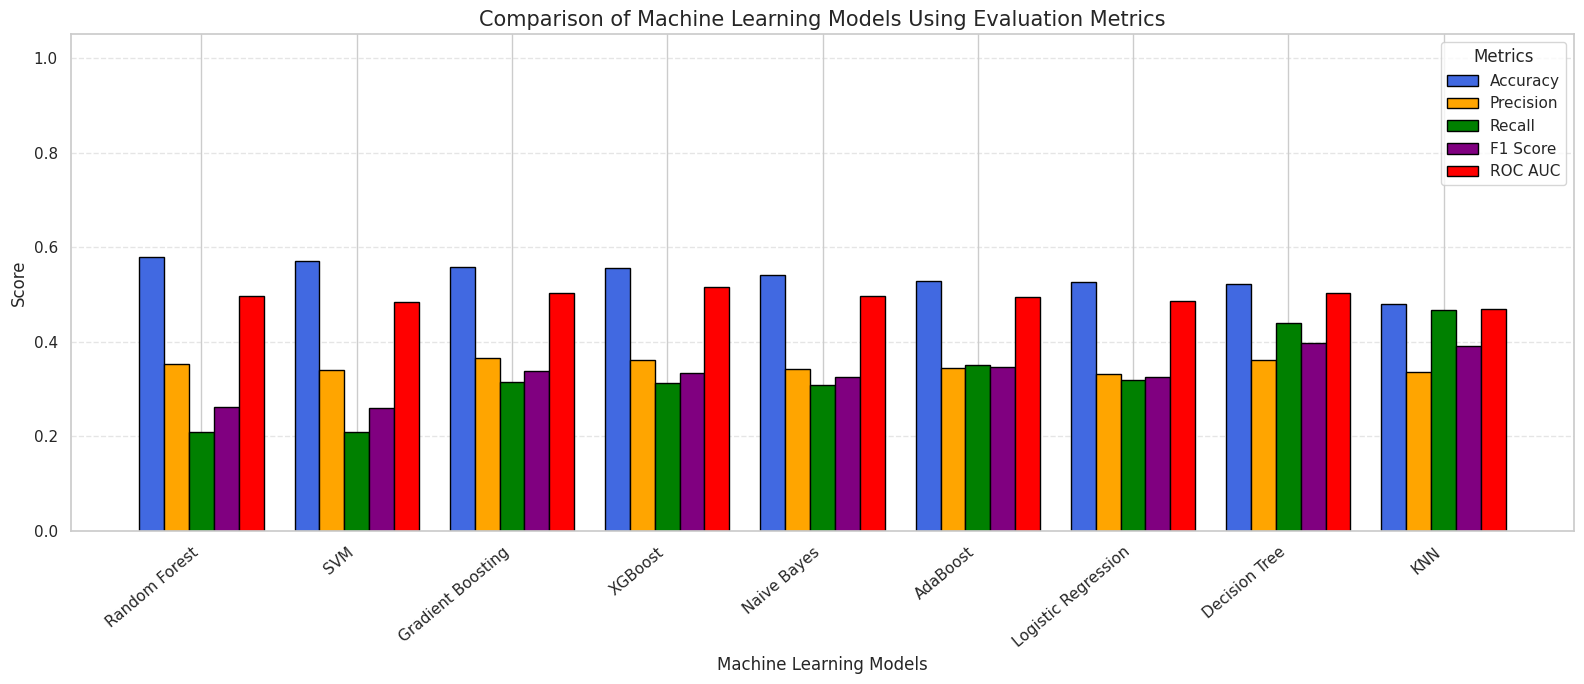

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics to compare
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

# Models
models = results_df["Model"]

# X-axis positions
x = np.arange(len(models))

# Width of each bar
width = 0.16

# Colors
colors = [
    "royalblue",
    "orange",
    "green",
    "purple",
    "red"
]

plt.figure(figsize=(16,7))

# Plot bars for each metric
for i, metric in enumerate(metrics):
    plt.bar(
        x + i*width,
        results_df[metric],
        width=width,
        label=metric,
        color=colors[i],
        edgecolor='black'
    )

plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Comparison of Machine Learning Models Using Evaluation Metrics", fontsize=15)

plt.xticks(
    x + width*2,
    models,
    rotation=40,
    ha='right'
)

plt.ylim(0, 1.05)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title="Metrics")

plt.tight_layout()

plt.show()

# BEST MODEL RANDOM FOREST CLASSIFIER

In [51]:
print("Best Model :", best["Model"])
print("Accuracy :", round(best["Accuracy"],4))

Best Model : Random Forest
Accuracy : 0.5796


In [52]:
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [53]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

# CONFUSION MATRIX RADOM FOREST

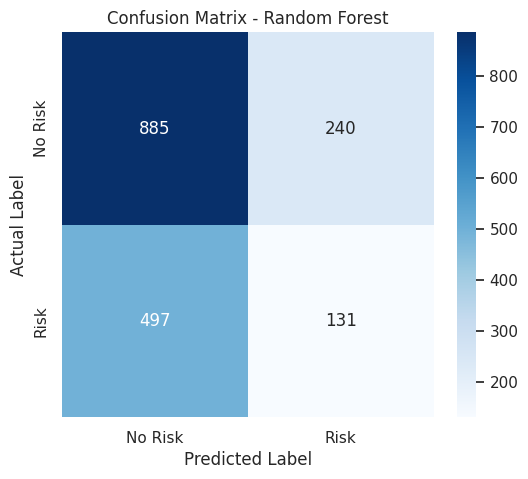

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Risk','Risk'],
    yticklabels=['No Risk','Risk']
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# CLASSICATION REPORT

In [55]:
from sklearn.metrics import classification_report

print("="*60)
print("CLASSIFICATION REPORT - RANDOM FOREST")
print("="*60)

print(classification_report(y_test, y_pred))

CLASSIFICATION REPORT - RANDOM FOREST
              precision    recall  f1-score   support

           0       0.64      0.79      0.71      1125
           1       0.35      0.21      0.26       628

    accuracy                           0.58      1753
   macro avg       0.50      0.50      0.48      1753
weighted avg       0.54      0.58      0.55      1753



# AUC ROC CURVE RANDOM FOREST

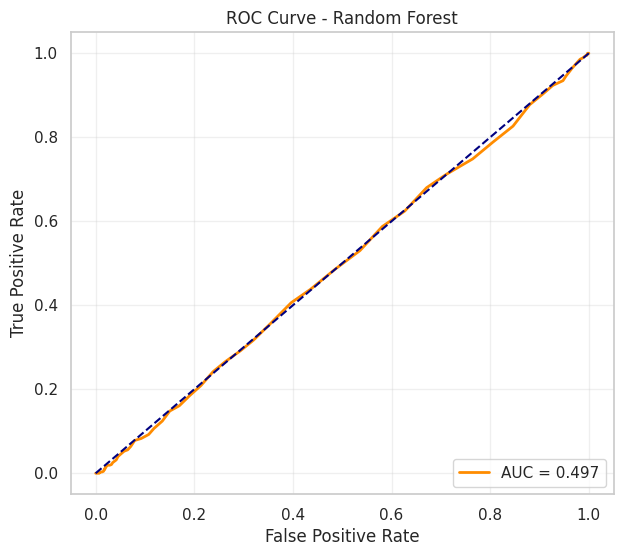

In [56]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr,
         color='darkorange',
         linewidth=2,
         label=f'AUC = {auc:.3f}')

plt.plot([0,1],[0,1],
         linestyle='--',
         color='navy')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

# FEATURE IMPORTANCE

In [57]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
9,Exercise Hours Per Week,0.069872
16,BMI,0.069456
2,Cholesterol,0.069254
14,Sedentary Hours Per Day,0.069197
15,Income,0.068408
17,Triglycerides,0.065651
23,Systolic_BP,0.063591
0,Age,0.063352
3,Heart Rate,0.062333
24,Diastolic_BP,0.061106


# FEATURE IMPORTANCE GRAPH

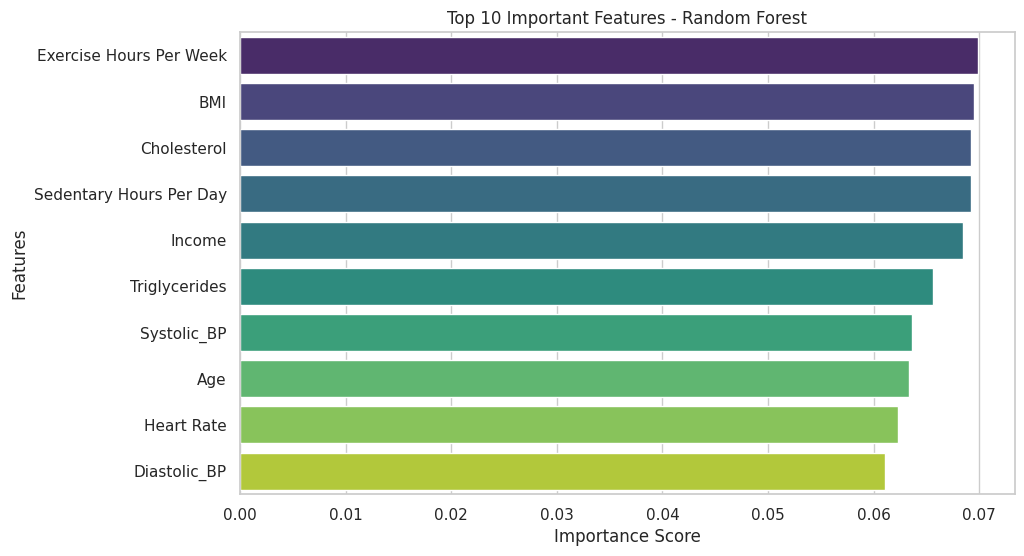

In [58]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# CROSS VALIDATION SCORE

In [59]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    RandomForestClassifier(random_state=42),
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Cross Validation Scores: [0.53611111 0.52055556 0.60166667 0.83713174 0.83324069]
Mean Accuracy: 0.6657411524921253
Standard Deviation: 0.14101005154118204
